In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    r2_score
)

In [2]:
# ----------------------------
# Configuration
# ----------------------------

PATH = "../data/raw/listings.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

# The list of columns to drop is based on a combination of domain knowledge, EDA insights, and practical considerations for modeling. It includes identifiers, URLs, metadata, text fields that are not being processed with NLP techniques, redundant information, and weak predictors. The goal is to simplify the feature space and focus on the most relevant features for predicting the target variable.
COLS_TO_DROP = [
    # identifiers / urls / metadata
    "id", "listing_url", "scrape_id", "source", "picture_url",
    "host_id", "host_url", "host_thumbnail_url", "host_picture_url",
    "calendar_updated", "calendar_last_scraped",

    # leakage
    "estimated_revenue_l365d", "estimated_occupancy_l365d",

    # text fields (no NLP)
    "name", "description", "neighborhood_overview", "host_about",

    # redundant text versions
    "bathrooms_text", "host_name", "host_verifications",

    # review score redundancy
    "review_scores_accuracy", "review_scores_checkin",
    "review_scores_communication", "review_scores_value",

    # availability redundancy
    "availability_60", "availability_eoy",

    # review activity redundancy
    "number_of_reviews_ltm", "number_of_reviews_l30d",
    "number_of_reviews_ly",

    # derived night statistics
    "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
    "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",

    # categorical removal from EDA
    "first_review", "last_review", "license",
    "host_location", "host_neighbourhood", "neighbourhood",
    "neighbourhood_group_cleansed", "has_availability",
    "host_identity_verified",

    # weak categorical predictor
    "host_response_time", "host_response_rate",
]

CLIP_COLS = [
    "beds",
    "bathrooms",
    "bedrooms",
    "minimum_nights",
    "maximum_nights",
    "host_acceptance_rate_num",
]

LOG_COLS = [
    "minimum_nights",
    "accommodates",
    "maximum_nights",
    "number_of_reviews",
    "reviews_per_month",
]

TOP_K = 10
AMENITIES_MIN_SHARE = 0.05

DISTANCE_POINTS = {
    "distance_to_bilbao":   (43.2630, -2.9350),
    "distance_to_donostia": (43.3183, -1.9812),
    "distance_to_vitoria":  (42.8467, -2.6726),
    "distance_to_coast":    (43.3623, -3.0136),
}

In [3]:
# ----------------------------
# Helper functions
# ----------------------------

def clean_price(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .replace("", np.nan)
        .astype(float)
    )

def clean_percentage(series: pd.Series) -> pd.Series:
    cleaned = (
        series.astype(str)
        .str.replace("%", "", regex=False)
        .replace({"nan": np.nan, "None": np.nan, "": np.nan})
    )
    return pd.to_numeric(cleaned, errors="coerce") / 100

def parse_amenities(amenity):
    if isinstance(amenity, list):
        parsed = amenity
    elif amenity == "" or amenity is None:
        return []
    else:
        try:
            parsed = ast.literal_eval(amenity)
        except(ValueError, SyntaxError):
            return[]
    return [str(a).strip().strip('"') for a in parsed if str(a).strip()]

def get_frequent_amenities(parsed_amenities, min_share):
    counts = dict()
    n = len(parsed_amenities)
    min_frequency = int(n * min_share)

    for row in parsed_amenities:
        for amenity in set(row):
            counts[amenity] = counts.get(amenity, 0) + 1 # 

    most_frequent = [amenity for amenity in counts if counts[amenity] >= min_frequency]
    
    return most_frequent

def df_encoded_amenities(df, parsed_amenities, most_frequent, luxury_keywords, original_column="amenities"):
    encoded_rows = []

    for row in parsed_amenities:
        row_set = set(row)
        encoded_row = []

        for amenity in most_frequent:
            if amenity in row_set:
                encoded_row.append(1)
            else:
                encoded_row.append(0)

        luxury_matches = 0
        for amenity in row:
            amenity_lower = amenity.lower()
            if any(keyword in amenity_lower for keyword in luxury_keywords):
                luxury_matches += 1

        has_luxury_amenity = 1 if luxury_matches > 0 else 0

        encoded_row.append(has_luxury_amenity)
        encoded_row.append(luxury_matches)

        encoded_rows.append(encoded_row)

    cleaned_columns = [
        amenity.replace(" ", "_")
        .replace("/", "_or_")
        .replace("-", "_")
        .replace(":", "")
        .replace(",", "")
        .replace("–", "")
        for amenity in most_frequent
    ]

    cleaned_columns.append("has_luxury_amenity")
    cleaned_columns.append("luxury_amenity_count")

    encoded_amenities_df = pd.DataFrame(
        encoded_rows,
        columns=cleaned_columns,
        index=parsed_amenities.index
    )

    df_transformed = df.drop(columns=[original_column]).join(encoded_amenities_df)

    return df_transformed
def distance_to_center(lat, lon):
    center_lat, center_lon = 43.263, -2.935
    distance = np.sqrt((lat - center_lat) ** 2 + (lon - center_lon) ** 2)
    return distance

In [4]:
# ----------------------------
# Custom transformers
# ----------------------------

class DropColumnsTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        return X.drop(columns=self.columns, errors="ignore")

class NumericLog1pTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        for col in self.columns:
            X[col] = np.log1p(X[col])
        return X
    
class NumericClipper(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        self.upper_ = {}
        self.lower_ = {}
        for col in self.columns:
            self.upper_[col] = X[col].quantile(0.99)
            self.lower_[col] = X[col].quantile(0.01)
        return self
    
    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[col] = X[col].clip(self.lower_[col], self.upper_[col])
        return X
    
class PriceToFloat(BaseEstimator, TransformerMixin):
    def __init__(self, column):
        self.column = column
    
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.column] = X[self.column].apply(clean_price)
        return X
    
class PercentageCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, column):
        self.column = column
    
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.column] = X[self.column].apply(clean_percentage)
        return X
    
class AmenitiesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column="amenities", min_share=0.05):
        self.column = column
        self.min_share = min_share

    def fit(self, X, y=None):
        parsed_amenities = X[self.column].apply(parse_amenities)
        self.most_frequent_ = get_frequent_amenities(parsed_amenities, self.min_share)

        self.luxury_keywords_ = [
            "view",
            "beachfront",
            "beach access",
            "pool",
            "hot tub",
            "fireplace",
            "gym",
            "ev charger"
        ]

        return self

    def transform(self, X):
        X = X.copy()
        parsed_amenities = X[self.column].apply(parse_amenities)
        X_transformed = df_encoded_amenities(
            X,
            parsed_amenities,
            self.most_frequent_,
            self.luxury_keywords_,
            original_column=self.column
        )
        return X_transformed
    
class HostExperienceTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, host_since_col="host_since", reference_col="last_scraped"):
        self.host_since_col = host_since_col
        self.reference_col = reference_col

    def fit(self, X, y=None):
        self.reference_date_ = pd.to_datetime(
            X[self.reference_col], errors="coerce"
        ).max()
        return self

    def transform(self, X):
        X = X.copy()

        host_since = pd.to_datetime(X[self.host_since_col], errors="coerce")

        X["host_experience_days"] = (
            self.reference_date_ - host_since
        ).dt.days

        return X.drop(columns=[self.host_since_col, self.reference_col], errors="ignore")


class DistanceFeaturesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, lat_col="latitude", lon_col="longitude", points=None):
        self.points = points or {}
        self.lat_col = lat_col
        self.lon_col = lon_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        lat = X[self.lat_col]
        lon = X[self.lon_col]

        for feature_name, (ref_lat, ref_lon) in self.points.items():
            X[feature_name] = np.sqrt((lat - ref_lat) ** 2 + (lon - ref_lon) ** 2)

        return X
    

class BinaryMapTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column, mapping):
        self.column = column
        self.mapping = mapping

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if self.column in X.columns:
            X[self.column] = X[self.column].map(self.mapping)
        return X


class TopKCategoryTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column, new_column=None, top_k=10, other_label="Other"):
        self.column = column
        self.new_column = new_column
        self.top_k = top_k
        self.other_label = other_label

    def fit(self, X, y=None):
        counts = X[self.column].value_counts(dropna=True)
        self.top_categories_ = counts.nlargest(self.top_k).index.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        cleaned = X[self.column].where(
            X[self.column].isin(self.top_categories_),
            self.other_label
        )
        target_column = self.new_column or self.column
        X[target_column] = cleaned
        if self.new_column is not None:
            X = X.drop(columns=[self.column])
        return X

In [5]:
# ------------------------------
# Load data and define target
# ------------------------------

df = pd.read_csv(PATH)

df["price"] = clean_price(df["price"])
df["host_response_rate"] = clean_percentage(df["host_response_rate"])
df["host_acceptance_rate"] = clean_percentage(df["host_acceptance_rate"])
df = df.rename(columns={"host_acceptance_rate": "host_acceptance_rate_num"})

df = df.dropna(subset=["price"]).copy()

df["log_price"] = np.log1p(df["price"])

df["price_bin"] = pd.qcut(df["price"], q=5, duplicates="drop")

df_train, df_test = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["price_bin"]
)

df_train = df_train.drop(columns=["price_bin"]).copy()
df_test = df_test.drop(columns=["price_bin"]).copy()

lower = df_train["log_price"].quantile(0.01)
upper = df_train["log_price"].quantile(0.99)

df_train["log_price"] = df_train["log_price"].clip(lower=lower, upper=upper)
df_test["log_price"] = df_test["log_price"].clip(lower=lower, upper=upper)

X_train = df_train.drop(columns=["price", "log_price"])
y_train = df_train["log_price"]

X_test = df_test.drop(columns=["price", "log_price"])
y_test = df_test["log_price"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4520, 78)
Test shape: (1131, 78)


In [6]:
# ----------------------------
# Shared feature-engineering pipeline
# ----------------------------

feature_engineering = Pipeline(
    steps=[
        ("drop_columns", DropColumnsTransformer(COLS_TO_DROP)),
        ("amenities", AmenitiesTransformer(column="amenities", min_share=AMENITIES_MIN_SHARE)),
        ("host_experience", HostExperienceTransformer()),
        ("distance_features", DistanceFeaturesTransformer(
            points=DISTANCE_POINTS
        )),
        ("clipper", NumericClipper(CLIP_COLS)),
        ("log1p", NumericLog1pTransformer(LOG_COLS)),
        ("instant_bookable_map", BinaryMapTransformer(
            column="instant_bookable",
            mapping={"t": 1, "f": 0}
        )),
        ("property_topk", TopKCategoryTransformer(
            column="property_type",
            new_column="property_type_clean",
            top_k=TOP_K
        )),
        ("neighbourhood_topk", TopKCategoryTransformer(
            column="neighbourhood_cleansed",
            new_column="neighbourhood_cleansed_clean",
            top_k=TOP_K
        )),
    ]
)

In [7]:
# ----------------------------
# Model-specific preprocessors
# ----------------------------

numeric_selector = make_column_selector(dtype_include=np.number)
categorical_selector = make_column_selector(dtype_exclude=np.number)

ridge_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_selector),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_selector),
    ],
    remainder="drop"
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), numeric_selector),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_selector),
    ],
    remainder="drop"
)

In [8]:
# ----------------------------
# Candidate pipelines
# ----------------------------

ridge_pipe = Pipeline([
    ("features", feature_engineering),
    ("preprocess", ridge_preprocessor),
    ("model", Ridge())
])

rf_pipe = Pipeline([
    ("features", feature_engineering),
    ("preprocess", tree_preprocessor),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

hgb_pipe = Pipeline([
    ("features", feature_engineering),
    ("preprocess", tree_preprocessor),
    ("model", HistGradientBoostingRegressor(
        random_state=RANDOM_STATE
    ))
])

In [9]:
# ----------------------------
# Hyperparameter tuning on training data only
# ----------------------------

ridge_grid = {
    "model__alpha": np.logspace(-3, 3, 25),
}

rf_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
}

hgb_grid = {
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_iter": [200, 300],
    "model__max_depth": [None, 6, 10],
    "model__min_samples_leaf": [10, 20, 30],
    "model__l2_regularization": [0.0, 0.1, 1.0],
}

In [10]:
ridge_search = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_grid,
    scoring="neg_root_mean_squared_error",
    cv=CV_FOLDS,
    n_jobs=-1,
    refit=True
)

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=CV_FOLDS,
    n_jobs=-1,
    refit=True,
    random_state=RANDOM_STATE
)

hgb_search = RandomizedSearchCV(
    estimator=hgb_pipe,
    param_distributions=hgb_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=CV_FOLDS,
    n_jobs=-1,
    refit=True,
    random_state=RANDOM_STATE
)

In [11]:
# WARNING:
# Running all three searches can take time.
# You can comment out the tree models temporarily if you want a faster pass.

ridge_search.fit(X_train, y_train)
print("Ridge best CV RMSE:", -ridge_search.best_score_)
print("Ridge best params:", ridge_search.best_params_)

Ridge best CV RMSE: 0.4233792752706721
Ridge best params: {'model__alpha': np.float64(1.7782794100389228)}


In [12]:
rf_search.fit(X_train, y_train)
print("RF best CV RMSE:", -rf_search.best_score_)
print("RF best params:", rf_search.best_params_)

RF best CV RMSE: 0.3632177546383029
RF best params: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': None}


In [13]:
hgb_search.fit(X_train, y_train)
print("HGB best CV RMSE:", -hgb_search.best_score_)
print("HGB best params:", hgb_search.best_params_)

HGB best CV RMSE: 0.3340985534003038
HGB best params: {'model__min_samples_leaf': 10, 'model__max_iter': 300, 'model__max_depth': 10, 'model__learning_rate': 0.1, 'model__l2_regularization': 0.0}


In [14]:
# ----------------------------
# Compare tuned models
# ----------------------------

completed_searches = []

for model_name, search in [
    ("ridge", ridge_search),
    ("random_forest", rf_search),
    ("hist_gradient_boosting", hgb_search),
]:
    if hasattr(search, "best_score_"):
        completed_searches.append({
            "model": model_name,
            "cv_rmse_log": -search.best_score_,
        })

if not completed_searches:
    raise ValueError("No completed model searches found. Run at least one search cell first.")

results = pd.DataFrame(completed_searches).sort_values("cv_rmse_log")

results

,model,cv_rmse_log
2,hist_gradient_boosting,0.334099
1,random_forest,0.363218
0,ridge,0.423379


In [15]:
# ----------------------------
# Select the best model
# ----------------------------

searches = {
    row["model"]: {
        "ridge": ridge_search,
        "random_forest": rf_search,
        "hist_gradient_boosting": hgb_search,
    }[row["model"]]
    for _, row in results.iterrows()
}

best_model_name = results.iloc[0]["model"]
best_search = searches[best_model_name]
best_pipeline = best_search.best_estimator_

print("Cross-validation results:")
print(results)

print("\nSelected final model:", best_model_name)
print("Best CV RMSE (log scale):", -best_search.best_score_)

Cross-validation results:
                    model  cv_rmse_log
2  hist_gradient_boosting     0.334099
1           random_forest     0.363218
0                   ridge     0.423379

Selected final model: hist_gradient_boosting
Best CV RMSE (log scale): 0.3340985534003038


In [16]:
# ----------------------------
# Final test evaluation
# ----------------------------

test_pred_log = best_pipeline.predict(X_test)

# 1) RMSE on log scale
test_rmse_log = root_mean_squared_error(y_test, test_pred_log)

# Convert back to euro scale
y_test_eur = np.expm1(y_test)
test_pred_eur = np.expm1(test_pred_log)

# 2) RMSE in euros
test_rmse_eur = root_mean_squared_error(y_test_eur, test_pred_eur)

# 3) MAE in euros
test_mae_eur = mean_absolute_error(y_test_eur, test_pred_eur)

# 4) Median Absolute Error in euros
test_medae_eur = median_absolute_error(y_test_eur, test_pred_eur)

# 5) R² on euro scale
test_r2 = r2_score(y_test_eur, test_pred_eur)

# Store results in a clean table
final_metrics = pd.DataFrame({
    "metric": [
        "RMSE (log scale)",
        "RMSE (€)",
        "MAE (€)",
        "Median AE (€)",
        "R²"
    ],
    "value": [
        test_rmse_log,
        test_rmse_eur,
        test_mae_eur,
        test_medae_eur,
        test_r2
    ]
})

print(f"Selected model: {best_model_name}\n")
display(final_metrics)

print("Final test results:")
print(f"RMSE (log scale): {test_rmse_log:.4f}")
print(f"RMSE (€): {test_rmse_eur:.2f}")
print(f"MAE (€): {test_mae_eur:.2f}")
print(f"Median AE (€): {test_medae_eur:.2f}")
print(f"R²: {test_r2:.4f}")

Selected model: hist_gradient_boosting



,metric,value
0,RMSE (log scale),0.325563
1,RMSE (€),95.450895
2,MAE (€),44.131504
3,Median AE (€),20.622140
4,R²,0.594550


Final test results:
RMSE (log scale): 0.3256
RMSE (€): 95.45
MAE (€): 44.13
Median AE (€): 20.62
R²: 0.5945


In [17]:
# ==============================
# Actual vs predicted examples
# ==============================

comparison_df = pd.DataFrame({
    "actual_price_eur": y_test_eur,
    "predicted_price_eur": test_pred_eur
}).reset_index(drop=True)

comparison_df["absolute_error_eur"] = (
    comparison_df["actual_price_eur"] - comparison_df["predicted_price_eur"]
).abs()

comparison_df["percentage_error"] = (
    comparison_df["absolute_error_eur"] / comparison_df["actual_price_eur"]
) * 100

print("Random sample of predictions:")
display(comparison_df.sample(10, random_state=42))

print("Worst predictions by absolute error:")
display(comparison_df.sort_values("absolute_error_eur", ascending=False).head(10))

print("Best predictions by absolute error:")
display(comparison_df.sort_values("absolute_error_eur", ascending=True).head(10))

Random sample of predictions:


,actual_price_eur,predicted_price_eur,absolute_error_eur,percentage_error
783,75.0,127.886757,52.886757,70.515676
898,93.0,82.551822,10.448178,11.234600
413,156.0,232.491751,76.491751,49.033174
467,32.0,40.569881,8.569881,26.780878
745,71.0,64.859545,6.140455,8.648528
109,105.0,107.067015,2.067015,1.968586
522,89.0,137.618602,48.618602,54.627643
56,138.0,128.865553,9.134447,6.619164
1111,193.0,220.362550,27.362550,14.177487
816,203.0,212.601840,9.601840,4.729971


Worst predictions by absolute error:


,actual_price_eur,predicted_price_eur,absolute_error_eur,percentage_error
971,1044.619705,174.175818,870.443887,83.326390
887,1044.619705,268.965100,775.654605,74.252343
649,850.000000,90.201188,759.798812,89.388096
772,1044.619705,315.863703,728.756002,69.762804
1003,1044.619705,316.470688,728.149018,69.704699
407,909.000000,193.474052,715.525948,78.715726
848,1044.619705,337.329583,707.290122,67.707905
398,1044.619705,345.964001,698.655705,66.881345
657,931.000000,352.688090,578.311910,62.117284
715,240.000000,815.019621,575.019621,239.591509


Best predictions by absolute error:


,actual_price_eur,predicted_price_eur,absolute_error_eur,percentage_error
1117,64.0,63.993466,0.006534,0.010210
210,93.0,92.990836,0.009164,0.009854
265,27.0,27.047048,0.047048,0.174253
135,225.0,224.934167,0.065833,0.029259
854,116.0,115.925431,0.074569,0.064283
884,106.0,105.898744,0.101256,0.095525
710,27.0,26.886774,0.113226,0.419357
851,196.0,195.866809,0.133191,0.067955
468,214.0,213.844981,0.155019,0.072439
749,73.0,72.753096,0.246904,0.338224


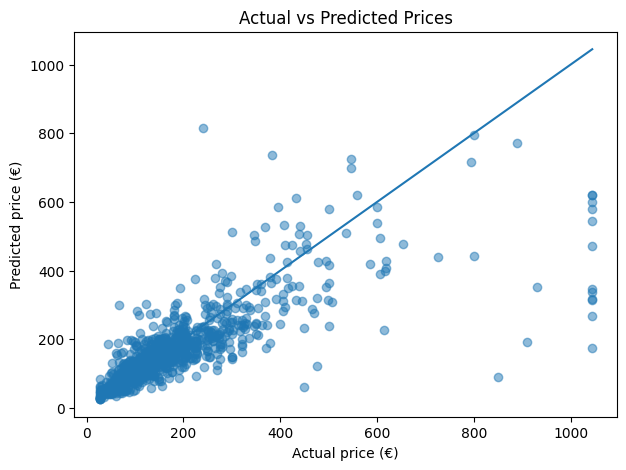

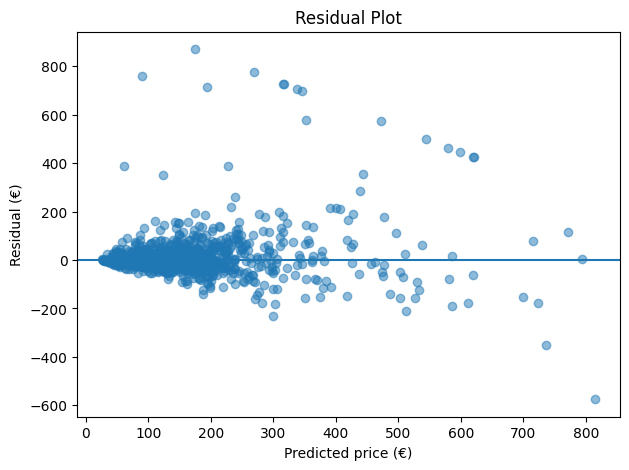

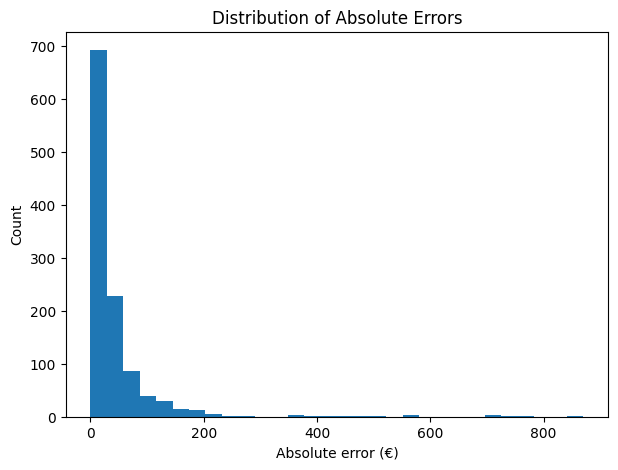

In [18]:
# Residuals
comparison_df["residual_eur"] = (
    comparison_df["actual_price_eur"] - comparison_df["predicted_price_eur"]
)

# 1) Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(
    comparison_df["actual_price_eur"],
    comparison_df["predicted_price_eur"],
    alpha=0.5
)

min_price = min(
    comparison_df["actual_price_eur"].min(),
    comparison_df["predicted_price_eur"].min()
)
max_price = max(
    comparison_df["actual_price_eur"].max(),
    comparison_df["predicted_price_eur"].max()
)

plt.plot([min_price, max_price], [min_price, max_price])
plt.xlabel("Actual price (€)")
plt.ylabel("Predicted price (€)")
plt.title("Actual vs Predicted Prices")
plt.show()


# 2) Residual plot
plt.figure(figsize=(7, 5))
plt.scatter(
    comparison_df["predicted_price_eur"],
    comparison_df["residual_eur"],
    alpha=0.5
)
plt.axhline(0)
plt.xlabel("Predicted price (€)")
plt.ylabel("Residual (€)")
plt.title("Residual Plot")
plt.show()


# 3) Histogram of absolute errors
plt.figure(figsize=(7, 5))
plt.hist(comparison_df["absolute_error_eur"], bins=30)
plt.xlabel("Absolute error (€)")
plt.ylabel("Count")
plt.title("Distribution of Absolute Errors")
plt.show()